In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from catboost import CatBoostClassifier

sns.set_theme(style='whitegrid')

# Прогноз удовлетворённости клиента для маркетплейса Olist

**Автор:** Данияр Баекеев<br>
**Дата:** Сентябрь 2026<br>
**Датасет:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)


---

## Введение

### Контекст
Olist — бразильский маркетплейс, объединяющий множество продавцов на одной платформе. Датасет содержит реальные анонимизированные данные о заказах, товарах, продавцах, оплатах, доставке и отзывах клиентов.

### Проблема
Низкая оценка клиента — это не только негативный отзыв, но и сигнал о проблемах с логистикой, стоимостью доставки, товаром или продавцом. Обычно бизнес узнаёт об этом уже после публикации отзыва.

### Вопрос
Можно ли предсказать, что клиент поставит низкую оценку (1–2 звезды), используя только данные, которые уже известны к моменту доставки заказа?

### Цель
Построить модель бинарной классификации, которая оценивает риск низкой оценки и позволяет заранее выделять заказы, требующие внимания клиентского сервиса.


---

### 1. Подготовка и очистка датасета

In [2]:
customers = pd.read_csv('datasets/olist_customers_dataset.csv')
geolocation = pd.read_csv('datasets/olist_geolocation_dataset.csv')
order_items = pd.read_csv('datasets/olist_order_items_dataset.csv')
order_payments = pd.read_csv('datasets/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('datasets/olist_order_reviews_dataset.csv')
orders = pd.read_csv('datasets/olist_orders_dataset.csv')
products = pd.read_csv('datasets/olist_products_dataset.csv')
sellers = pd.read_csv('datasets/olist_sellers_dataset.csv')
category_translation = pd.read_csv('datasets/product_category_name_translation.csv')

tables = {
    'customers': customers,
    'geolocation': geolocation,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

In [3]:
# Быстрая диагностика пропусков по всем таблицам
diagnostics = []

for table_name, df in tables.items():
    for col in df.columns:
        diagnostics.append({
            'Таблица': table_name,
            'Признак': col,
            'Тип данных': str(df[col].dtype),
            'Пропуски': int(df[col].isna().sum()),
            'Пропуски (%)': round(df[col].isna().mean() * 100, 2),
            'Уникальных значений': int(df[col].nunique(dropna=False))
        })

report_df = pd.DataFrame(diagnostics)

print('Топ-20 признаков по доле пропусков:')
display(
    report_df
    .sort_values('Пропуски (%)', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

Топ-20 признаков по доле пропусков:


,Таблица,Признак,Тип данных,Пропуски,Пропуски (%),Уникальных значений
0,order_reviews,review_comment_title,str,87656,88.34,4528
1,order_reviews,review_comment_message,str,58247,58.70,36160
2,orders,order_delivered_customer_date,str,2965,2.98,95665
3,products,product_name_lenght,float64,610,1.85,67
4,products,product_photos_qty,float64,610,1.85,20
5,products,product_category_name,str,610,1.85,74
6,products,product_description_lenght,float64,610,1.85,2961
7,orders,order_delivered_carrier_date,str,1783,1.79,81019
8,orders,order_approved_at,str,160,0.16,90734
9,products,product_weight_g,float64,2,0.01,2205


### 2. Построение реляционной БД (SQLite) и SQL-агрегации

In [4]:
# Создаём SQLite-базу и загружаем в неё все 9 таблиц
DB_PATH = 'olist_capstone.db'
conn = sqlite3.connect(DB_PATH)

sql_table_names = {
    'customers': 'customers',
    'geolocation': 'geolocation',
    'order_items': 'order_items',
    'order_payments': 'order_payments',
    'order_reviews': 'order_reviews',
    'orders': 'orders',
    'products': 'products',
    'sellers': 'sellers',
    'category_translation': 'category_translation',
}

for key, sql_name in sql_table_names.items():
    tables[key].to_sql(sql_name, conn, if_exists='replace', index=False)

# Индексируем
index_queries = [
    'CREATE INDEX IF NOT EXISTS idx_orders_order_id ON orders(order_id);',
    'CREATE INDEX IF NOT EXISTS idx_orders_customer_id ON orders(customer_id);',
    'CREATE INDEX IF NOT EXISTS idx_customers_customer_id ON customers(customer_id);',
    'CREATE INDEX IF NOT EXISTS idx_items_order_id ON order_items(order_id);',
    'CREATE INDEX IF NOT EXISTS idx_items_product_id ON order_items(product_id);',
    'CREATE INDEX IF NOT EXISTS idx_items_seller_id ON order_items(seller_id);',
    'CREATE INDEX IF NOT EXISTS idx_payments_order_id ON order_payments(order_id);',
    'CREATE INDEX IF NOT EXISTS idx_reviews_order_id ON order_reviews(order_id);',
    'CREATE INDEX IF NOT EXISTS idx_products_product_id ON products(product_id);',
    'CREATE INDEX IF NOT EXISTS idx_sellers_seller_id ON sellers(seller_id);',
]

for query in index_queries:
    conn.execute(query)

conn.commit()

In [5]:
# Схема связей между таблицами
relationships = pd.DataFrame([
    ['orders', 'customer_id', 'customers', 'customer_id', 'многие заказы -> один customer_id'],
    ['order_items', 'order_id', 'orders', 'order_id', 'много позиций -> один заказ'],
    ['order_items', 'product_id', 'products', 'product_id', 'позиция -> товар'],
    ['order_items', 'seller_id', 'sellers', 'seller_id', 'позиция -> продавец'],
    ['order_payments', 'order_id', 'orders', 'order_id', 'много платежей -> один заказ'],
    ['order_reviews', 'order_id', 'orders', 'order_id', 'отзыв -> заказ'],
    ['products', 'product_category_name', 'category_translation', 'product_category_name', 'перевод категории'],
    ['customers', 'customer_zip_code_prefix', 'geolocation', 'geolocation_zip_code_prefix', 'география, опционально'],
    ['sellers', 'seller_zip_code_prefix', 'geolocation', 'geolocation_zip_code_prefix', 'география, опционально'],
], columns=['Таблица A', 'Ключ A', 'Таблица B', 'Ключ B', 'Связь'])

In [6]:
# Формируем признаки на уровне одного заказа

sql_query = '''
WITH item_agg AS (
    SELECT
        oi.order_id,
        COUNT(*) AS item_count,
        COUNT(DISTINCT oi.product_id) AS product_count,
        COUNT(DISTINCT oi.seller_id) AS seller_count,
        SUM(oi.price) AS total_price,
        SUM(oi.freight_value) AS total_freight,
        AVG(oi.price) AS avg_item_price,
        AVG(p.product_weight_g) AS avg_product_weight_g,
        AVG(
            CASE
                WHEN p.product_length_cm IS NOT NULL
                 AND p.product_height_cm IS NOT NULL
                 AND p.product_width_cm IS NOT NULL
                THEN p.product_length_cm * p.product_height_cm * p.product_width_cm
            END
        ) AS avg_product_volume_cm3
    FROM order_items oi
    LEFT JOIN products p
        ON oi.product_id = p.product_id
    GROUP BY oi.order_id
),

first_item AS (
    SELECT
        oi.order_id,
        COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS primary_category,
        s.seller_state AS primary_seller_state,
        s.seller_city AS primary_seller_city
    FROM order_items oi
    LEFT JOIN products p
        ON oi.product_id = p.product_id
    LEFT JOIN category_translation t
        ON p.product_category_name = t.product_category_name
    LEFT JOIN sellers s
        ON oi.seller_id = s.seller_id
    WHERE oi.order_item_id = 1
),

payment_agg AS (
    SELECT
        order_id,
        SUM(payment_value) AS total_payment_value,
        MAX(payment_installments) AS max_payment_installments,
        COUNT(*) AS payment_records,
        MAX(CASE WHEN payment_type = 'credit_card' THEN 1 ELSE 0 END) AS pay_credit_card,
        MAX(CASE WHEN payment_type = 'boleto' THEN 1 ELSE 0 END) AS pay_boleto,
        MAX(CASE WHEN payment_type = 'voucher' THEN 1 ELSE 0 END) AS pay_voucher,
        MAX(CASE WHEN payment_type = 'debit_card' THEN 1 ELSE 0 END) AS pay_debit_card
    FROM order_payments
    GROUP BY order_id
),

review_ranked AS (
    SELECT
        order_id,
        review_score,
        review_creation_date,
        review_answer_timestamp,
        ROW_NUMBER() OVER (
            PARTITION BY order_id
            ORDER BY review_answer_timestamp DESC, review_creation_date DESC
        ) AS rn
    FROM order_reviews
),

review_one AS (
    SELECT order_id, review_score
    FROM review_ranked
    WHERE rn = 1
)

SELECT
    o.order_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    c.customer_state,
    c.customer_city,

    ia.item_count,
    ia.product_count,
    ia.seller_count,
    ia.total_price,
    ia.total_freight,
    ia.avg_item_price,
    ia.avg_product_weight_g,
    ia.avg_product_volume_cm3,

    fi.primary_category,
    fi.primary_seller_state,
    fi.primary_seller_city,

    pa.total_payment_value,
    pa.max_payment_installments,
    pa.payment_records,
    pa.pay_credit_card,
    pa.pay_boleto,
    pa.pay_voucher,
    pa.pay_debit_card,

    CAST(
        julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)
        AS REAL
    ) AS delivery_time_days,

    CAST(
        julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date)
        AS REAL
    ) AS delivery_delay_days,

    CAST(
        julianday(o.order_estimated_delivery_date) - julianday(o.order_purchase_timestamp)
        AS REAL
    ) AS promised_delivery_days,

    CAST(
        (julianday(o.order_approved_at) - julianday(o.order_purchase_timestamp)) * 24
        AS REAL
    ) AS approval_time_hours,

    CAST(
        julianday(o.order_delivered_customer_date) - julianday(o.order_delivered_carrier_date)
        AS REAL
    ) AS carrier_to_customer_days,

    CASE
        WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1
        ELSE 0
    END AS is_late,

    CAST(strftime('%w', o.order_purchase_timestamp) AS INTEGER) AS purchase_weekday,
    CAST(strftime('%H', o.order_purchase_timestamp) AS INTEGER) AS purchase_hour,

    r.review_score

FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN item_agg ia
    ON o.order_id = ia.order_id
LEFT JOIN first_item fi
    ON o.order_id = fi.order_id
LEFT JOIN payment_agg pa
    ON o.order_id = pa.order_id
JOIN review_one r
    ON o.order_id = r.order_id

WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL;
'''

df_final = pd.read_sql_query(sql_query, conn)

print(f'Итоговая таблица на уровне заказа: {df_final.shape[0]:,} строк, {df_final.shape[1]} столбцов')

Итоговая таблица на уровне заказа: 95,824 строк, 36 столбцов


In [7]:
# Проверяем главный принцип: одна строка = один заказ
duplicate_orders = df_final['order_id'].duplicated().sum()

print(f'Дубликатов order_id: {duplicate_orders}')
assert duplicate_orders == 0, 'После SQL-сборки появились дубликаты заказов.'

final_missing = (
    df_final.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename('Пропуски (%)')
    .to_frame()
)

display(final_missing.head(15))

Дубликатов order_id: 0


,Пропуски (%)
avg_product_weight_g,0.016697
avg_product_volume_cm3,0.016697
order_approved_at,0.014610
approval_time_hours,0.014610
pay_credit_card,0.001044
pay_debit_card,0.001044
pay_voucher,0.001044
order_delivered_carrier_date,0.001044
max_payment_installments,0.001044
payment_records,0.001044


### 3. Разведочный анализ данных (EDA)

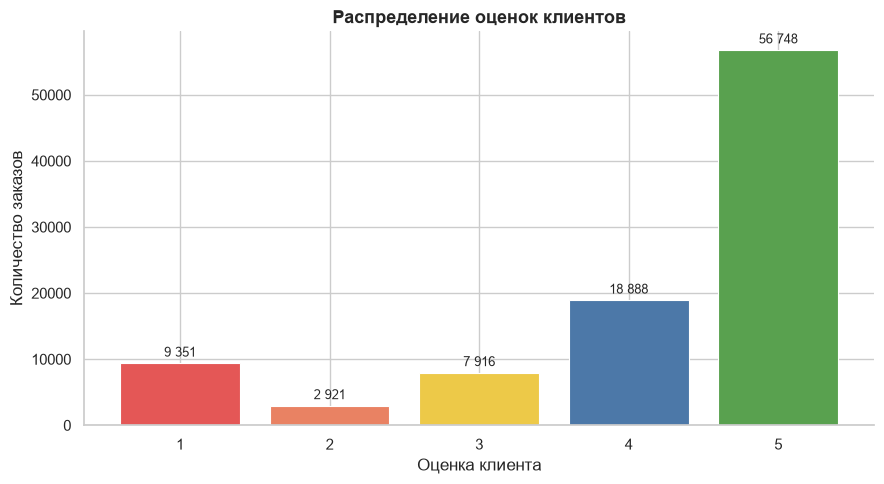

In [8]:
BLUE = '#4C78A8'
RED = '#E45756'
GREEN = '#59A14F'
ORANGE = '#F28E2B'
YELLOW = '#EDC948'

review_distribution = (
    df_final['review_score']
    .value_counts()
    .sort_index()
    .rename_axis('review_score')
    .reset_index(name='orders')
)

rating_colors = [RED, '#E98263', YELLOW, BLUE, GREEN]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    review_distribution['review_score'].astype(str),
    review_distribution['orders'],
    color=rating_colors,
    edgecolor='white',
    linewidth=0.8
)

ax.set_title('Распределение оценок клиентов', fontsize=13, fontweight='bold')
ax.set_xlabel('Оценка клиента')
ax.set_ylabel('Количество заказов')

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{int(height):,}'.replace(',', ' '),
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Вывод:**

Низкие оценки 1–2 звезды составляют 12.8% заказов. Поэтому задача является несбалансированной, и обычной Accuracy для оценки модели будет недостаточно.

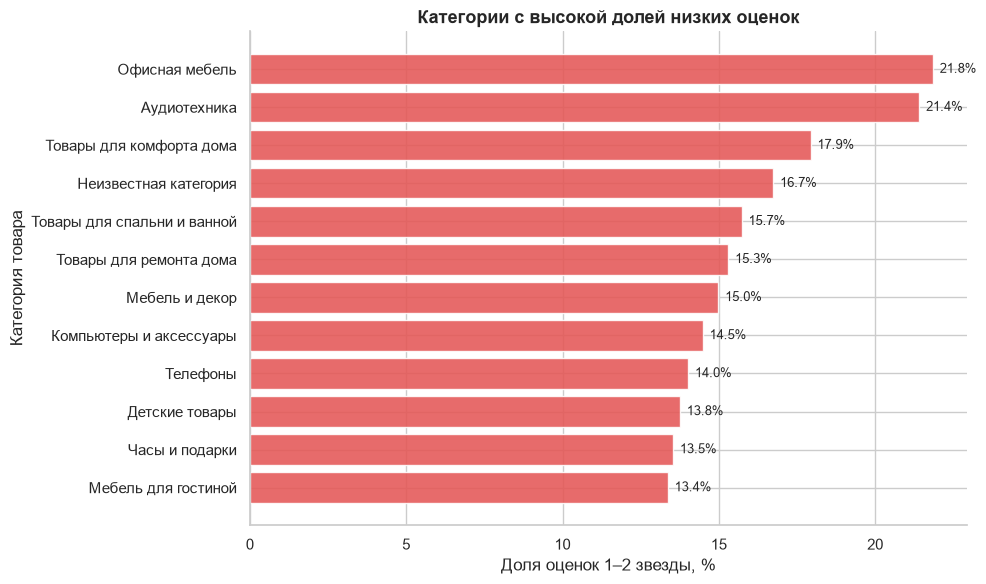

In [9]:
category_stat = (
    df_final
    .groupby('primary_category')
    .agg(
        orders=('order_id', 'count'),
        low_rating_rate=('review_score', lambda x: (x <= 2).mean() * 100)
    )
    .reset_index()
)

category_stat = category_stat[category_stat['orders'] >= 300]
category_stat = category_stat.sort_values('low_rating_rate', ascending=False).head(12)
category_translation_ru = {
    'office_furniture': 'Офисная мебель',
    'audio': 'Аудиотехника',
    'home_confort': 'Товары для комфорта дома',
    'unknown': 'Неизвестная категория',
    'bed_bath_table': 'Товары для спальни и ванной',
    'home_construction': 'Товары для ремонта дома',
    'furniture_decor': 'Мебель и декор',
    'computers_accessories': 'Компьютеры и аксессуары',
    'telephony': 'Телефоны',
    'baby': 'Детские товары',
    'watches_gifts': 'Часы и подарки',
    'furniture_living_room': 'Мебель для гостиной'
}

category_stat['category_ru'] = (
    category_stat['primary_category']
    .map(category_translation_ru)
    .fillna(category_stat['primary_category'])
)

plot_cat = category_stat.sort_values('low_rating_rate')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    plot_cat['category_ru'],
    plot_cat['low_rating_rate'],
    color=RED,
    alpha=0.88
)

ax.set_title(
    'Категории с высокой долей низких оценок',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('Доля оценок 1–2 звезды, %')
ax.set_ylabel('Категория товара')

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width, bar.get_y() + bar.get_height() / 2),
        ha='left',
        va='center',
        fontsize=9,
        xytext=(5, 0),
        textcoords='offset points'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


**Вывод:**

Риск низкой оценки зависит не только от логистики. Между товарными категориями также есть различия, поэтому категорию товара имеет смысл сохранить среди признаков.

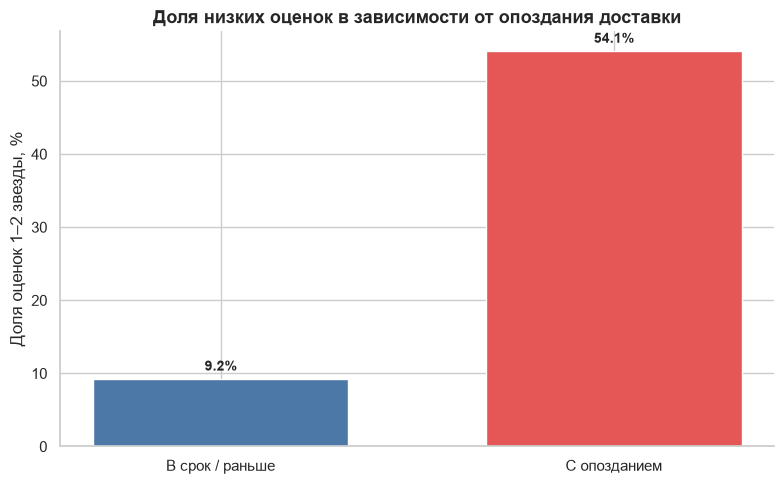

In [10]:
eda_delivery = df_final.copy()

eda_delivery['Низкая оценка'] = np.where(
    eda_delivery['review_score'] <= 2,
    '1–2 звезды',
    '3–5 звёзд'
)

eda_delivery['Статус доставки'] = np.where(
    eda_delivery['is_late'] == 1,
    'С опозданием',
    'В срок / раньше'
)

late_stat = (
    eda_delivery
    .groupby('Статус доставки')['review_score']
    .apply(lambda x: (x <= 2).mean() * 100)
    .reset_index(name='low_rating_rate')
)

status_order = ['В срок / раньше', 'С опозданием']
late_stat['Статус доставки'] = pd.Categorical(
    late_stat['Статус доставки'],
    categories=status_order,
    ordered=True
)
late_stat = late_stat.sort_values('Статус доставки')

bar_colors = [
    BLUE if status == 'В срок / раньше' else RED
    for status in late_stat['Статус доставки'].astype(str)
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    late_stat['Статус доставки'].astype(str),
    late_stat['low_rating_rate'],
    color=bar_colors,
    width=0.65
)

ax.set_title(
    'Доля низких оценок в зависимости от опоздания доставки',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('')
ax.set_ylabel('Доля оценок 1–2 звезды, %')

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        xytext=(0, 4),
        textcoords='offset points'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Вывод:**

Среди заказов с опозданием доля оценок 1–2 составляет 54.1%, а среди доставленных вовремя или раньше — 9.2%. Отношение рисков составляет примерно 5.86x.

### 4. Подготовка целевой переменной

Исходная оценка клиента принимает значения от 1 до 5 звёзд.
Для дальнейшего машинного обучения преобразуем задачу в бинарную классификацию:
- target = 1 — клиент поставил 1–2 звезды;
- target = 0 — клиент поставил 3–5 звёзд.
Такое разделение позволяет сфокусироваться именно на заказах с явно негативным клиентским опытом.

In [11]:
df_ml = df_final.copy()

# Создаём бинарную целевую переменную
df_ml['target'] = (df_ml['review_score'] <= 2).astype(int)

target_distribution = (
    df_ml['target']
    .value_counts()
    .sort_index()
    .rename(index={0: '3-5 звёзд', 1: '1-2 звезды'})
)

print('Распределение классов:')
print(target_distribution)
print()
print('Доли классов, %:')
print((target_distribution / len(df_ml) * 100).round(2))

Распределение классов:
target
3-5 звёзд     83552
1-2 звезды    12272
Name: count, dtype: int64

Доли классов, %:
target
3-5 звёзд     87.19
1-2 звезды    12.81
Name: count, dtype: float64


### 5. Машинное обучение

In [12]:
# Исключаем целевую переменную, прямую утечку и служебные поля
drop_cols = [
    'review_score',
    'target',
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'customer_city',
    'primary_seller_city',
]

X = df_ml.drop(columns=drop_cols, errors='ignore').copy()
y = df_ml['target'].copy()

cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = X.select_dtypes(include=['number', 'bool']).columns.tolist()

# Train / validation / test = 70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f'Всего признаков до кодирования: {X.shape[1]}')
print(f'Числовых: {len(num_cols)}')
print(f'Категориальных: {len(cat_cols)}')
print('\nКатегориальные признаки:', cat_cols)

Всего признаков до кодирования: 26
Числовых: 23
Категориальных: 3

Категориальные признаки: ['customer_state', 'primary_category', 'primary_seller_state']


In [13]:
# Logistic Regression
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1500,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

lr_valid_probs = lr_pipeline.predict_proba(X_valid)[:, 1]
lr_test_probs = lr_pipeline.predict_proba(X_test)[:, 1]

print('Logistic Regression обучена.')

Logistic Regression обучена.


In [14]:
# CatBoost Classifier
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()
X_test_cb = X_test.copy()

for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].fillna('Missing').astype(str)
    X_valid_cb[col] = X_valid_cb[col].fillna('Missing').astype(str)
    X_test_cb[col] = X_test_cb[col].fillna('Missing').astype(str)

for col in num_cols:
    train_median = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(train_median)
    X_valid_cb[col] = X_valid_cb[col].fillna(train_median)
    X_test_cb[col] = X_test_cb[col].fillna(train_median)

cb_model = CatBoostClassifier(
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=8,
    auto_class_weights='Balanced',
    cat_features=cat_cols,
    random_seed=42,
    verbose=0
)

cb_model.fit(
    X_train_cb,
    y_train,
    eval_set=(X_valid_cb, y_valid),
    early_stopping_rounds=100,
    verbose=0
)

cb_valid_probs = cb_model.predict_proba(X_valid_cb)[:, 1]
cb_test_probs = cb_model.predict_proba(X_test_cb)[:, 1]

print(f'CatBoost обучен.')

CatBoost обучен.


In [15]:
def find_best_threshold(y_true, probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)

    best_idx = np.argmax(f1_scores[:-1])
    return thresholds[best_idx], f1_scores[best_idx]

lr_threshold, lr_valid_f1 = find_best_threshold(y_valid, lr_valid_probs)
cb_threshold, cb_valid_f1 = find_best_threshold(y_valid, cb_valid_probs)

print(f'Лучший threshold Logistic Regression по validation: {lr_threshold:.4f}')
print(f'Лучший threshold CatBoost по validation:            {cb_threshold:.4f}')

Лучший threshold Logistic Regression по validation: 0.5816
Лучший threshold CatBoost по validation:            0.6412


In [16]:
# Сравнение моделей на отложенном test
def evaluate_model(name, y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)

    return {
        'Model': name,
        'ROC-AUC': roc_auc_score(y_true, probs),
        'PR-AUC': average_precision_score(y_true, probs),
        'Precision': precision_score(y_true, preds, zero_division=0),
        'Recall': recall_score(y_true, preds, zero_division=0),
        'F1': f1_score(y_true, preds, zero_division=0),
        'Threshold': threshold,
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, lr_test_probs, lr_threshold),
    evaluate_model('CatBoost', y_test, cb_test_probs, cb_threshold),
])

baseline_pr = y_test.mean()

print(f'PR-AUC случайного классификатора примерно равен доле класса 1: {baseline_pr:.4f}')

PR-AUC случайного классификатора примерно равен доле класса 1: 0.1281


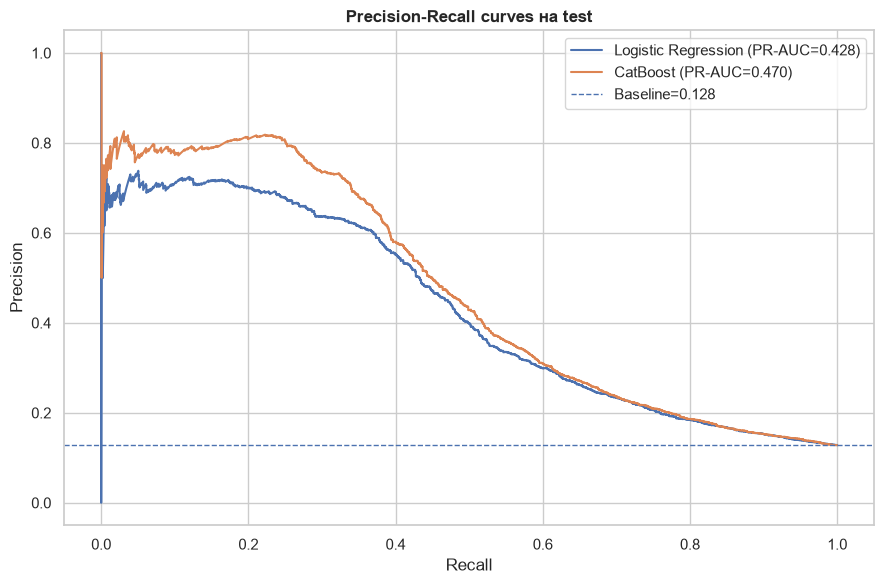

In [17]:
plt.figure(figsize=(9, 6))

for name, probs in [
    ('Logistic Regression', lr_test_probs),
    ('CatBoost', cb_test_probs)
]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=f'{name} (PR-AUC={average_precision_score(y_test, probs):.3f})')

plt.axhline(
    baseline_pr,
    linestyle='--',
    linewidth=1,
    label=f'Baseline={baseline_pr:.3f}'
)

plt.title('Precision-Recall curves на test', fontsize=12, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
best_model_name = results.sort_values('PR-AUC', ascending=False).iloc[0]['Model']

if best_model_name == 'CatBoost':
    best_probs = cb_test_probs
    best_threshold = cb_threshold
else:
    best_probs = lr_test_probs
    best_threshold = lr_threshold

best_preds = (best_probs >= best_threshold).astype(int)
cm = confusion_matrix(y_test, best_preds)

cm_df = pd.DataFrame(
    cm,
    index=['Факт: 3-5 звёзд', 'Факт: 1-2 звезды'],
    columns=['Прогноз: 3-5', 'Прогноз: 1-2']
)

print(f'Матрица ошибок для {best_model_name}:')

Матрица ошибок для CatBoost:


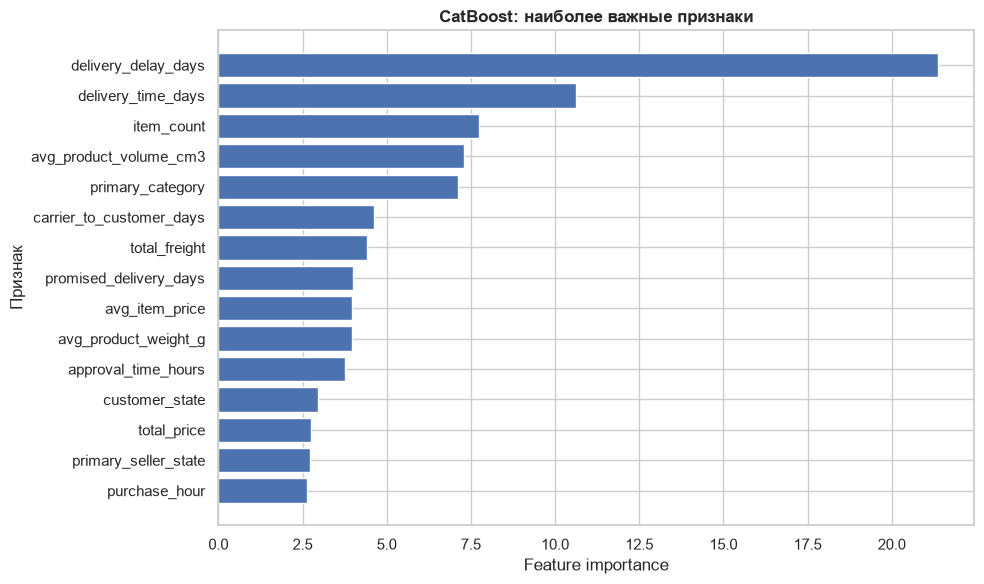

In [19]:
feature_importance = pd.DataFrame({
    'feature': X_train_cb.columns,
    'importance': cb_model.get_feature_importance()
}).sort_values('importance', ascending=False)

top_cb_features = feature_importance.head(15)
plot_imp = top_cb_features.sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_imp['feature'], plot_imp['importance'])
ax.set_title('CatBoost: наиболее важные признаки', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature importance')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()

In [20]:
lr_feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
lr_coef = lr_pipeline.named_steps['classifier'].coef_[0]

lr_importance = pd.DataFrame({
    'feature': lr_feature_names,
    'coefficient': lr_coef,
    'abs_coefficient': np.abs(lr_coef)
}).sort_values('abs_coefficient', ascending=False)

In [21]:
ranked = pd.DataFrame({
    'target': y_test.to_numpy(),
    'probability': best_probs
}).sort_values(
    'probability',
    ascending=False
)

top_n = max(
    1,
    int(np.ceil(len(ranked) * 0.10))
)

top_10 = ranked.head(top_n)

base_rate = ranked['target'].mean()
top_10_rate = top_10['target'].mean()

lift_10 = (
    top_10_rate / base_rate
    if base_rate > 0
    else np.nan
)

print(f'Средняя доля низких оценок: {base_rate:.1%}')
print(f'Доля низких оценок в Top-10% риска: {top_10_rate:.1%}')
print(f'Lift@10%: {lift_10:.2f}x')

Средняя доля низких оценок: 12.8%
Доля низких оценок в Top-10% риска: 54.2%
Lift@10%: 4.24x


In [22]:
best_row = results.sort_values('PR-AUC', ascending=False).iloc[0]
top_features_text = ', '.join(feature_importance.head(5)['feature'].tolist())

print('Интерпретация результатов')
print()

print(
    f'Основная метрика: из-за дисбаланса классов главным показателем выбран PR-AUC. '
    f'Базовый уровень PR-AUC, соответствующий случайному ранжированию, составляет примерно {baseline_pr:.3f}.'
)

print(
    f'Сравнение моделей: на test лучшая модель по PR-AUC — {best_model_name}. '
    f'Её PR-AUC = {best_row["PR-AUC"]:.3f}, '
    f'ROC-AUC = {best_row["ROC-AUC"]:.3f}.'
)

print(
    f'Рабочий порог: threshold подбирался только на validation, а не на test. '
    f'На test при этом пороге Precision = {best_row["Precision"]:.3f}, '
    f'Recall = {best_row["Recall"]:.3f}, '
    f'F1 = {best_row["F1"]:.3f}.'
)

print(
    f'Главные признаки CatBoost: среди наиболее важных факторов оказались: '
    f'{top_features_text}.'
)

print(
    f'Практическая ценность ранжирования: в Top-10% заказов с самым высоким прогнозируемым риском '
    f'доля низких оценок составляет {top_10_rate:.1%} против {base_rate:.1%} в среднем. '
    f'Lift@10% = {lift_10:.2f}x.'
)

print()
print('Бизнес-вывод и применение')
print()

print(
    'Модель лучше использовать не как автоматическое решение «компенсировать / не компенсировать», '
    'а как инструмент приоритизации заказов по риску. '
    'Клиентский сервис может сфокусироваться на небольшой группе заказов '
    'с максимальной предсказанной вероятностью оценки 1–2 звезды.'
)

print()
print('На практике это может означать:')
print('1. проактивное сообщение после проблемной доставки;')
print('2. ускоренную обработку обращения;')
print('3. небольшой промокод или компенсацию для наиболее рискованных случаев;')
print('4. отдельный мониторинг продавцов, категорий и логистических сценариев с повышенным риском.')

print()

print(
    'Главное ограничение модели — она использует только признаки, доступные в Olist. '
    'В данных нет полной информации о качестве самого товара, содержании общения с поддержкой '
    'и индивидуальных ожиданиях клиента, поэтому предсказание следует применять '
    'как риск-скоринг, а не как безошибочное решение.'
)

Интерпретация результатов

Основная метрика: из-за дисбаланса классов главным показателем выбран PR-AUC. Базовый уровень PR-AUC, соответствующий случайному ранжированию, составляет примерно 0.128.
Сравнение моделей: на test лучшая модель по PR-AUC — CatBoost. Её PR-AUC = 0.470, ROC-AUC = 0.759.
Рабочий порог: threshold подбирался только на validation, а не на test. На test при этом пороге Precision = 0.515, Recall = 0.438, F1 = 0.474.
Главные признаки CatBoost: среди наиболее важных факторов оказались: delivery_delay_days, delivery_time_days, item_count, avg_product_volume_cm3, primary_category.
Практическая ценность ранжирования: в Top-10% заказов с самым высоким прогнозируемым риском доля низких оценок составляет 54.2% против 12.8% в среднем. Lift@10% = 4.24x.

Бизнес-вывод и применение

Модель лучше использовать не как автоматическое решение «компенсировать / не компенсировать», а как инструмент приоритизации заказов по риску. Клиентский сервис может сфокусироваться на небольшой гру